# Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Read the dataset

In [2]:
df = pd.read_csv("Loan_default_cleaned.csv")

print(df.head())
print(df.shape)
print(df.columns)

       loanid       age    income  loanamount  creditscore  monthsemployed  \
0  I38PQUQS96  0.833990  0.089693   -1.086833    -0.341492        0.590533   
1  HPSK72WA7R  1.701221 -0.823021   -0.044309    -0.731666       -1.285731   
2  C1OZ6DPJ8Y  0.166888  0.043854    0.022715    -0.775718       -0.968209   
3  V2KKSFM3UN -0.767053 -1.303452   -1.168538     1.061875       -1.718715   
4  EY08JDHTZP  1.100830 -1.592855   -1.671921     0.369631       -1.487790   

   numcreditlines  interestrate  loanterm  dtiratio  education  \
0        1.341937      0.261771 -0.001526 -0.260753          0   
1       -1.343791     -1.308350  1.412793  0.778585          2   
2        0.446694      1.156831 -0.708685 -0.823728          2   
3        0.446694     -0.967805 -0.708685 -1.170174          1   
4        1.341937     -1.052188  0.705634  0.995114          0   

   employmenttype  maritalstatus  hasmortgage  hasdependents  loanpurpose  \
0               0              0            1            

# Separate Input and Output

In [3]:
x = df.drop(columns = ["loanid", "default"])
y = df["default"]

In [4]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (255347, 16)
y shape: (255347,)


# Split the dataset

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
)

In [6]:
print(y_train.value_counts())

default
0    180524
1     23753
Name: count, dtype: int64


# Create Decision Tree

In [21]:
depths = [3, 5, 7, 10, 15, 20]

for depth in depths:

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    print("Max Depth:", depth)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Max Depth: 3
Accuracy: 0.8844722929312708
[[45170     0]
 [ 5900     0]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     45170
           1       0.00      0.00      0.00      5900

    accuracy                           0.88     51070
   macro avg       0.44      0.50      0.47     51070
weighted avg       0.78      0.88      0.83     51070

--------------------------------------------------


/home/nafisa/D Drive/Nafisa college materials/ML/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nafisa/D Drive/Nafisa college materials/ML/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nafisa/D Drive/Nafisa college materials/ML/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

Max Depth: 5
Accuracy: 0.8854317603289602
[[45082    88]
 [ 5763   137]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.61      0.02      0.04      5900

    accuracy                           0.89     51070
   macro avg       0.75      0.51      0.49     51070
weighted avg       0.85      0.89      0.84     51070

--------------------------------------------------
Max Depth: 7
Accuracy: 0.8852946935578617
[[45019   151]
 [ 5707   193]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.56      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.72      0.51      0.50     51070
weighted avg       0.85      0.89      0.84     51070

--------------------------------------------------
Max Depth: 10
Accuracy: 0.8826512629723908
[[44660   510]
 [ 5483   417]]
              precision 

In [22]:
depths = [3, 5, 7, 10, 15, 20]

for depth in depths:

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    print("Max Depth:", depth)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Max Depth: 3
Accuracy: 0.6918934795378892
[[31884 13286]
 [ 2449  3451]]
              precision    recall  f1-score   support

           0       0.93      0.71      0.80     45170
           1       0.21      0.58      0.30      5900

    accuracy                           0.69     51070
   macro avg       0.57      0.65      0.55     51070
weighted avg       0.85      0.69      0.74     51070

--------------------------------------------------
Max Depth: 5
Accuracy: 0.6901899353828079
[[31576 13594]
 [ 2228  3672]]
              precision    recall  f1-score   support

           0       0.93      0.70      0.80     45170
           1       0.21      0.62      0.32      5900

    accuracy                           0.69     51070
   macro avg       0.57      0.66      0.56     51070
weighted avg       0.85      0.69      0.74     51070

--------------------------------------------------
Max Depth: 7
Accuracy: 0.6831603681221853
[[31110 14060]
 [ 2121  3779]]
              precision  

In [7]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    random_state=42
)

# Train the model

In [8]:
model.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

# Make predictions

In [9]:
y_pred = model.predict(x_test)

In [10]:
print(y_pred)

[0 0 0 ... 0 0 0]


In [11]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result.head(20))

    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        0          0
8        0          0
9        0          0
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       0          0
18       0          0
19       1          0


# Calculate Accuracy

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8826512629723908
Accuracy (%): 88.26512629723908


# Confusion Matrix

In [13]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[44660   510]
 [ 5483   417]]


In [14]:
pd.set_option("display.max_rows", None)

print(result)

       Actual  Predicted
0           0          0
1           0          0
2           0          0
3           0          0
4           0          0
5           0          0
6           0          0
7           0          0
8           0          0
9           0          0
10          0          0
11          0          0
12          0          0
13          0          0
14          0          0
15          0          0
16          0          0
17          0          0
18          0          0
19          1          0
20          0          0
21          0          0
22          1          0
23          0          0
24          0          0
25          0          0
26          0          0
27          0          0
28          0          0
29          0          0
30          0          0
31          0          0
32          0          0
33          0          0
34          0          0
35          0          0
36          0          0
37          0          0
38          0          0


In [15]:
pd.reset_option("display.max_rows")

# Classification Report

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45170
           1       0.45      0.07      0.12      5900

    accuracy                           0.88     51070
   macro avg       0.67      0.53      0.53     51070
weighted avg       0.84      0.88      0.84     51070



# Probability prediction

In [17]:
y_probability = model.predict_proba(x_test)
print(y_probability[:10])

[[0.9591528  0.0408472 ]
 [0.93764434 0.06235566]
 [0.8844376  0.1155624 ]
 [0.90909091 0.09090909]
 [0.85519126 0.14480874]
 [0.84464902 0.15535098]
 [0.97173471 0.02826529]
 [0.96551724 0.03448276]
 [0.97686375 0.02313625]
 [0.92986301 0.07013699]]


# Check feature importance

In [18]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
0              age    0.221556
1           income    0.192770
6     interestrate    0.180735
2       loanamount    0.164239
4   monthsemployed    0.107666
3      creditscore    0.043575
8         dtiratio    0.021704
10  employmenttype    0.014881
15     hascosigner    0.009925
13   hasdependents    0.008827
14     loanpurpose    0.008004
5   numcreditlines    0.007092
9        education    0.006763
7         loanterm    0.005117
11   maritalstatus    0.003864
12     hasmortgage    0.003282


# Visualize the Decision Tree

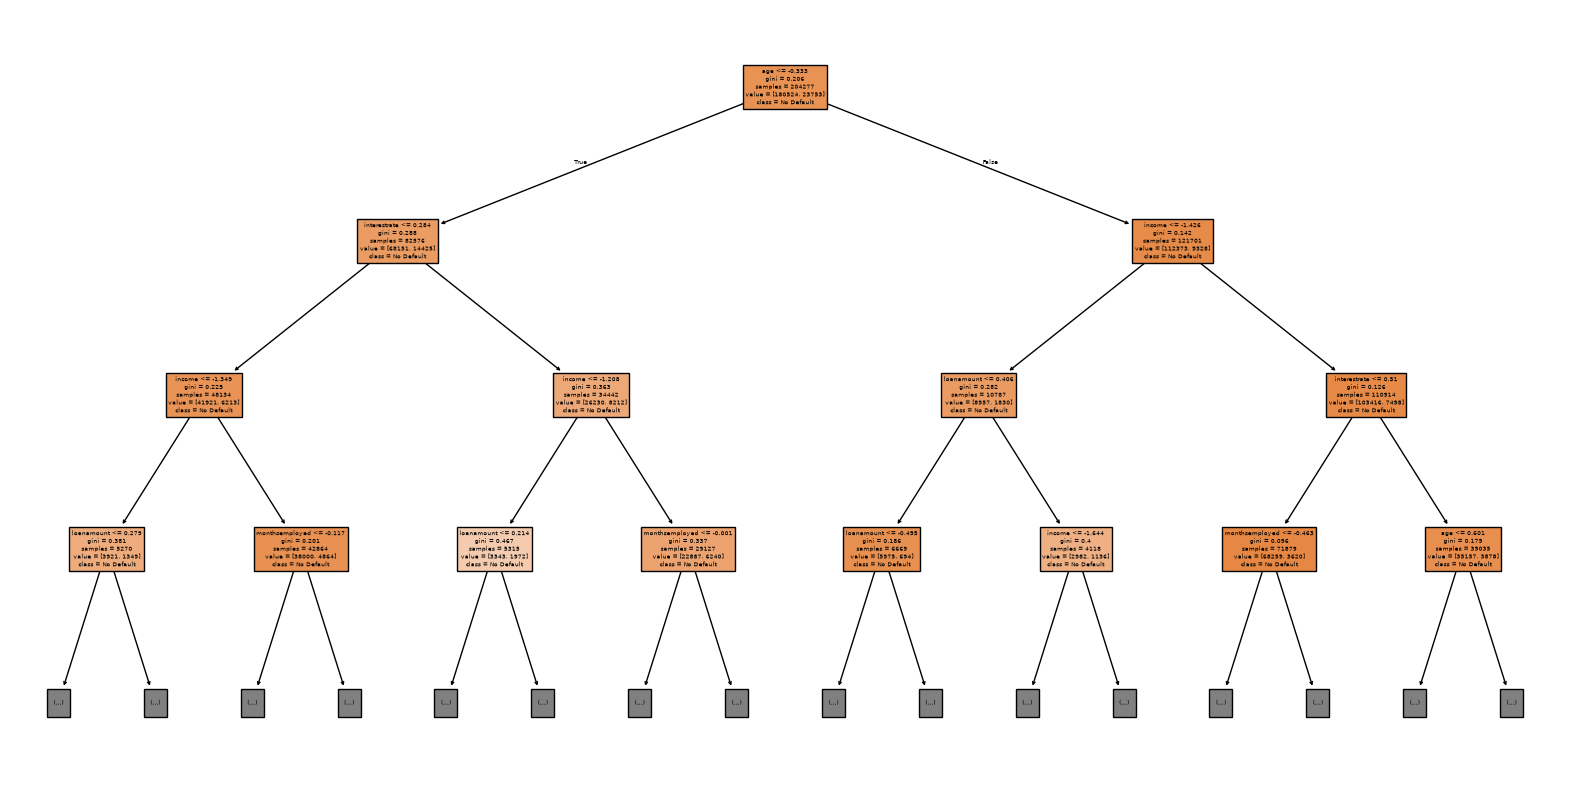

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=["No Default", "Default"],
    filled=True,
    max_depth=3
)

plt.show()